In [2]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt

experiment = "one_img_diff_pix_no_seg"

CSV_PATH = f"../results/{experiment}/combined_results.csv"
SAVE_FIGS = True
FIG_DIR = "figs"

df = pd.read_csv(CSV_PATH)

In [ ]:
def parse_eps_from_vnnlib(vnnlib: str):
    if not isinstance(vnnlib, str):
        return np.nan
    m = re.search(r"eps[_=]([0-9]*\.?[0-9]+)", vnnlib)
    return float(m.group(1)) if m else np.nan

def parse_seg_from_vnnlib(vnnlib: str):
    if not isinstance(vnnlib, str):
        return np.nan
    m = re.search(r"_seg(\d+)_", vnnlib)
    return int(m.group(1)) if m else np.nan

def normalize_result(s: str):
    """Map raw result strings into consistent labels.

    Returns:
      attack_label in {SAT, UNSAT, None}
      bnb_label in {safe, timeout, other, None}
    """
    if not isinstance(s, str):
        return (None, None)

    ss = s.strip().lower()

    # Attack interpretation
    attack = None
    if "sat" in ss:
        attack = "SAT"
    if "unsat" in ss:
        # make UNSAT override plain 'sat' substring cases (rare)
        attack = "UNSAT"

    # BnB interpretation
    bnb = None
    if "timeout" in ss:
        bnb = "timeout"
    elif "safe" in ss or "verified" in ss or "unsat true" in ss:
        # depending on your pipeline, safe might be explicit or implied
        bnb = "safe"
    elif "sat" in ss:
        # sat means counterexample found; not safe
        bnb = "counterexample"
    else:
        bnb = "other"

    return (attack, bnb)

# Fill eps/segment if missing
if "eps" not in df.columns or df["eps"].isna().all():
    df["eps"] = df["vnnlib"].apply(parse_eps_from_vnnlib)

if "segment_index" not in df.columns or df["segment_index"].isna().all():
    df["segment_index"] = df["vnnlib"].apply(parse_seg_from_vnnlib)

# Parse outcomes
parsed = df["result"].apply(normalize_result)
df["attack_outcome"] = parsed.apply(lambda x: x[0])
df["bnb_outcome"] = parsed.apply(lambda x: x[1])

# Keep rows with a defined k/num_changed and eps
df_clean = df.copy()
df_clean = df_clean[~df_clean["num_changed"].isna()]
df_clean = df_clean[~df_clean["eps"].isna()]

df_clean["eps_str"] = df_clean["eps"].map(lambda x: f"{x:g}")
sorted_eps = sorted(df_clean["eps"].dropna().unique())

print("clean:", df_clean.shape)
df_clean[["eps","k","num_changed","result","attack_outcome","bnb_outcome","bab_time","all_time","domains_visited"]].head(10)


clean: (252, 26)


,eps,k,num_changed,result,attack_outcome,bnb_outcome,bab_time,all_time,domains_visited
0,0.0001,15,45,timeout False,None,timeout,1280.064666,1286.970044,30.0
1,0.0001,30,90,timeout False,None,timeout,1441.609780,1451.232700,15.0
2,0.0001,45,135,NaN,None,None,NaN,NaN,NaN
3,0.0001,60,180,NaN,None,None,NaN,NaN,NaN
4,0.0001,75,225,NaN,None,None,NaN,NaN,NaN
5,0.0001,90,270,NaN,None,None,NaN,NaN,NaN
6,0.0001,105,315,NaN,None,None,NaN,NaN,NaN
7,0.0001,120,360,NaN,None,None,NaN,NaN,NaN
8,0.0001,135,405,NaN,None,None,NaN,NaN,NaN
9,0.0001,151,453,NaN,None,None,NaN,NaN,NaN


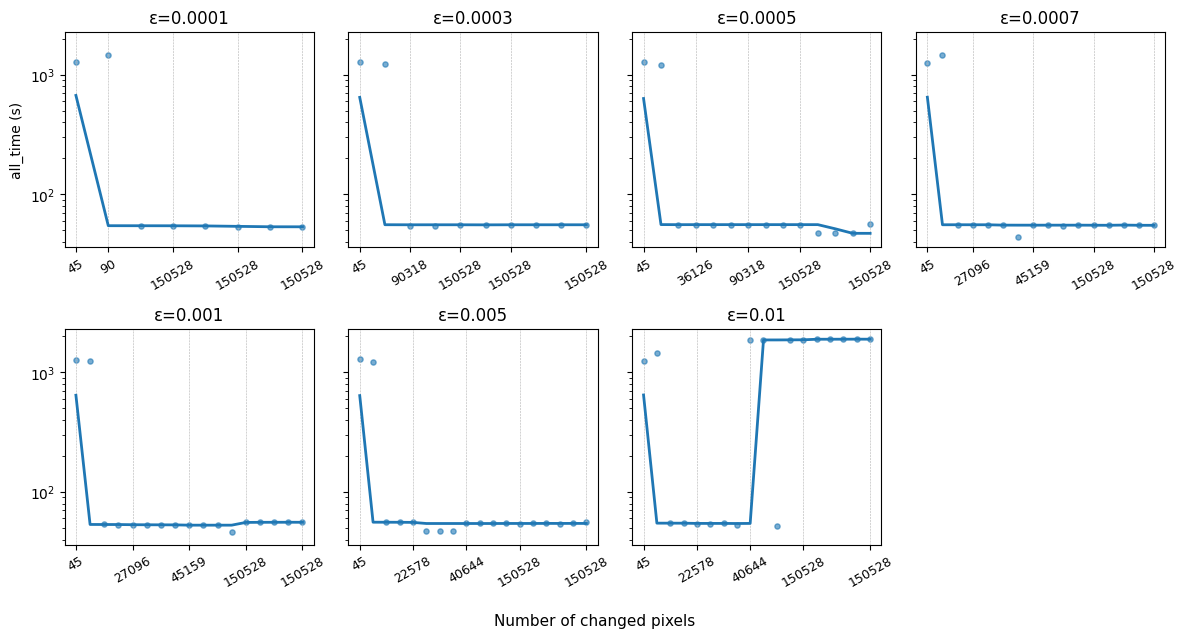

In [10]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ensure_fig_dir():
    if SAVE_FIGS:
        os.makedirs(FIG_DIR, exist_ok=True)

ensure_fig_dir()

TIME_COL = "all_time" if "all_time" in df_clean.columns else "bab_time"

ROLLING_WINDOW = 7
SMOOTH_METHOD = "median"
MIN_POINTS = 3

# Clean data (NOTE: use num_changed, not pct_change)
d = df_clean.dropna(subset=[TIME_COL, "num_changed", "eps"]).copy()
d["eps_str"] = d["eps"].map(lambda x: f"{x:g}")

eps_list = sorted(d["eps"].unique())
n_eps = len(eps_list)

# ---- 2-row layout ----
N_ROWS = 2
N_COLS = math.ceil(n_eps / N_ROWS)

fig, axes = plt.subplots(
    N_ROWS, N_COLS,
    figsize=(3 * N_COLS, 3.2 * N_ROWS),
    sharey=True
)

axes = axes.flatten()

for ax, eps in zip(axes, eps_list):
    epss = f"{eps:g}"
    sub = d[d["eps_str"] == epss].sort_values("num_changed")

    if len(sub) < MIN_POINTS:
        ax.set_title(f"ε={epss}\n(no data)")
        ax.axis("off")
        continue

    # ---- ORDINAL X (even spacing) ----
    x_pos = np.arange(len(sub))               # evenly spaced
    x_labels = sub["num_changed"].astype(int).astype(str).to_list()

    y = sub[TIME_COL].to_numpy()

    # smoothing over ordinal axis
    y_series = pd.Series(y)
    if SMOOTH_METHOD == "mean":
        y_smooth = y_series.rolling(
            ROLLING_WINDOW, center=True, min_periods=1
        ).mean()
    else:
        y_smooth = y_series.rolling(
            ROLLING_WINDOW, center=True, min_periods=1
        ).median()

    # raw points
    ax.scatter(x_pos, y, s=14, alpha=0.6)

    # smooth trend
    ax.plot(x_pos, y_smooth, linewidth=2)

    ax.set_title(f"ε={epss}", fontsize=12)
    ax.grid(True, axis="x", linestyle="--", linewidth=0.4)

    # fewer x ticks for readability
    tick_idx = np.linspace(0, len(x_pos) - 1, min(5, len(x_pos))).astype(int)
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([x_labels[i] for i in tick_idx], rotation=30, fontsize=9)

# turn off unused subplots
for ax in axes[len(eps_list):]:
    ax.axis("off")

axes[0].set_ylabel(f"{TIME_COL} (s)")
fig.supxlabel("Number of changed pixels", fontsize=11)

plt.yscale("log")
plt.tight_layout()

if SAVE_FIGS:
    plt.savefig(
        f"{FIG_DIR}/time_vs_num_changed_small_multiples_eps_2rows.pdf",
        dpi=300,
        bbox_inches="tight"
    )

plt.show()

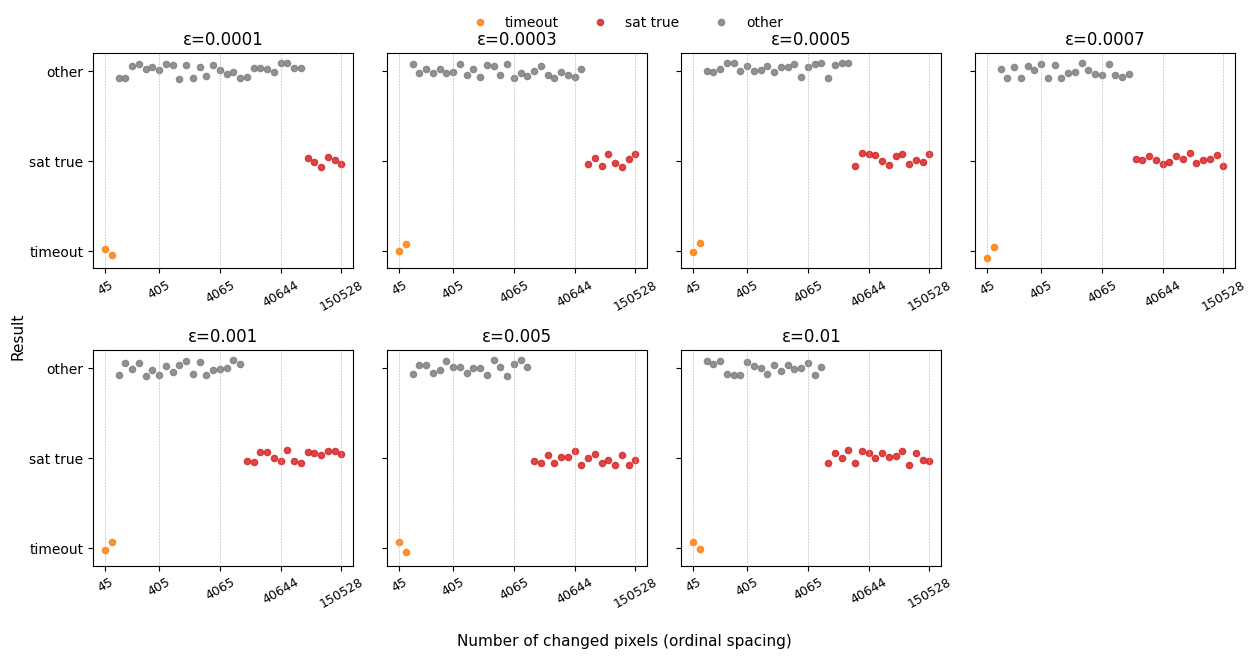

In [24]:
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------
# 1) Map "result" column -> y categories
# ---------------------------------------
def map_result(r):
    if pd.isna(r):
        return "other"
    r = str(r).strip().lower()

    # common patterns seen in your CSV like: "timeout False", "safe True", etc.
    if "timeout" in r:
        return "timeout"
    if "safe" in r and "true" in r:
        return "safe true"
    if "safe" in r and "false" in r:
        return "safe false"

    # optional: if your result column ever contains SAT/UNSAT
    if "sat" in r and "true" in r:
        return "sat true"
    if "sat" in r and "false" in r:
        return "sat false"

    return "other"

# ---------------------------------------
# 2) Prep data (ONLY from result column)
# ---------------------------------------
d = df.dropna(subset=["num_changed", "eps"]).copy()
d["eps_str"] = d["eps"].map(lambda x: f"{x:g}")
d["y_cat"] = d["result"].apply(map_result)

# preferred order of categories on y-axis
ORDER = ["safe true", "safe false", "timeout", "sat true", "sat false", "other"]

# keep only categories that exist, but in your fixed order
present = [c for c in ORDER if c in set(d["y_cat"].unique())]

COLOR_MAP = {
    "safe true":  "#1f77b4",
    "safe false": "#aec7e8",
    "timeout":    "#ff7f0e",
    "sat true":   "#d62728",
    "sat false":  "#ff9896",
    "other":      "#7f7f7f",
}

# numeric y positions for jittering
y_to_num = {c: i for i, c in enumerate(present)}
d["y_num"] = d["y_cat"].map(y_to_num)

# ---------------------------------------
# 3) Small multiples layout (one panel per eps)
# ---------------------------------------
eps_list = sorted(d["eps"].dropna().unique())
N_ROWS = 2
N_COLS = math.ceil(len(eps_list) / N_ROWS)

fig, axes = plt.subplots(
    N_ROWS, N_COLS,
    figsize=(3.2 * N_COLS, 3.2 * N_ROWS),
    sharey=True,
    squeeze=False
)
axes = axes.flatten()

rng = np.random.default_rng(0)

for ax, eps in zip(axes, eps_list):
    epss = f"{eps:g}"
    sub = d[d["eps_str"] == epss].sort_values("num_changed")

    if sub.empty:
        ax.set_title(f"ε={epss}\n(no data)")
        ax.axis("off")
        continue

    # ordinal x positions (equal spacing)
    x_pos = np.arange(len(sub))
    x_labels = sub["num_changed"].astype(int).astype(str).to_list()

    # numeric y + jitter
    y_num = sub["y_num"].astype(float).to_numpy()
    y_jitter = y_num + (rng.random(len(y_num)) - 0.5) * 0.18

    # plot categories in your chosen order, only if present
    for cat in present:
        mask = (sub["y_cat"] == cat).to_numpy()
        if not mask.any():
            continue
        ax.scatter(
            x_pos[mask], y_jitter[mask],
            s=20, alpha=0.85,
            color=COLOR_MAP.get(cat, "#7f7f7f"),
            label=cat
        )

    ax.set_title(f"ε={epss}", fontsize=12)
    ax.grid(True, axis="x", linestyle="--", linewidth=0.4)

    # readable x ticks
    tick_idx = np.linspace(0, len(x_pos) - 1, min(5, len(x_pos))).astype(int)
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([x_labels[i] for i in tick_idx], rotation=30, fontsize=9)

# turn off unused subplots
for ax in axes[len(eps_list):]:
    ax.axis("off")

# y-axis ticks/labels = RESULTS ✅
axes[0].set_yticks(range(len(present)))
axes[0].set_yticklabels(present, fontsize=10)

# If you want the first item in ORDER at the TOP, uncomment:
# axes[0].invert_yaxis()

fig.supxlabel("Number of changed pixels (ordinal spacing)", fontsize=11)
fig.supylabel("Result", fontsize=11)

# one legend for the whole figure (dedup)
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(), by_label.keys(),
    loc="upper center",
    ncol=min(4, len(by_label)),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout()

if "SAVE_FIGS" in globals() and SAVE_FIGS:
    os.makedirs(FIG_DIR, exist_ok=True)
    plt.savefig(
        f"{FIG_DIR}/result_vs_num_changed_from_result_column.pdf",
        dpi=300,
        bbox_inches="tight"
    )

plt.show()